In [35]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates


In [21]:
df = pd.read_csv(r"C:\Users\salma\Downloads\Source_2_Fixtures_2026_Chicago_Stars_All_Competitions.csv")
df.head()

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent,Poss,Attendance,Captain,Formation,Opp Formation,Referee,Match Report,Notes
0,2026-03-15,16:00 (01:00),NWSL,Regular Season,Sun,Away,L,0.0,4.0,Angel City FC,40.0,16813.0,Alyssa Naeher,4-2-3-1,4-3-1-2,Shawn Tehini,Match Report,NaN
1,2026-03-22,13:00 (20:00),NWSL,Regular Season,Sun,Away,W,2.0,1.0,Current,50.0,4192.0,Alyssa Naeher,4-2-3-1,4-3-3,Alex Billeter,Match Report,NaN
2,2026-03-25,19:00 (02:00),NWSL,Regular Season,Wed,Home,L,2.0,3.0,Orlando Pride,52.0,1821.0,Alyssa Naeher,4-2-3-1,4-2-3-1,Matthew Thompson,Match Report,NaN
3,2026-03-28,17:45 (02:45),NWSL,Regular Season,Sat,Away,L,0.0,2.0,SD Wave,41.0,12810.0,Alyssa Naeher,4-2-3-1,4-2-3-1,Servando Berna Rico,Match Report,NaN
4,2026-04-03,19:00 (03:00),NWSL,Regular Season,Fri,Away,L,0.0,1.0,Royals,39.0,10012.0,Kathrin Hendrich,4-2-3-1,4-2-3-1,Trevor Wiseman,Match Report,NaN


In [22]:
df.dtypes

Date                 str
Time                 str
Comp                 str
Round                str
Day                  str
Venue                str
Result               str
GF               float64
GA               float64
Opponent             str
Poss             float64
Attendance       float64
Captain              str
Formation            str
Opp Formation        str
Referee              str
Match Report         str
Notes            float64
dtype: object

In [23]:

# Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Convert numeric columns
float_cols = ["GF", "GA", "Poss", "Attendance", "Notes"]
for col in float_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

# Convert string columns
str_cols = [
    "Time",
    "Comp",
    "Round",
    "Day",
    "Venue",
    "Result",
    "Opponent",
    "Captain",
    "Formation",
    "Opp Formation",
    "Referee",
    "Match Report",
]
for col in str_cols:
    df[col] = df[col].astype("string")

# Check resulting column dtypes
print(df.dtypes)

Date             datetime64[us]
Time                     string
Comp                     string
Round                    string
Day                      string
Venue                    string
Result                   string
GF                      float64
GA                      float64
Opponent                 string
Poss                    float64
Attendance              float64
Captain                  string
Formation                string
Opp Formation            string
Referee                  string
Match Report             string
Notes                   float64
dtype: object


In [24]:
df.isna().sum()

Date              0
Time              0
Comp              0
Round             0
Day               0
Venue             0
Result            7
GF                7
GA                7
Opponent          0
Poss              7
Attendance        7
Captain           7
Formation         7
Opp Formation     7
Referee           7
Match Report      0
Notes            30
dtype: int64

In [25]:
df.shape

(30, 18)

# Win / Draw / Loss rate

In [26]:
# Calculate total counts and percentage rates
counts = df["Result"].value_counts()
rates = df["Result"].value_counts(normalize=True) * 100

# Combine into a structured Summary DataFrame
wdl_summary = pd.DataFrame(
    {"Count": counts, "Rate (%)": rates.round(2)}
).reindex(["W", "D", "L"], fill_value=0)

print(wdl_summary)

        Count  Rate (%)
Result                 
W           6     26.09
D           1      4.35
L          16     69.57


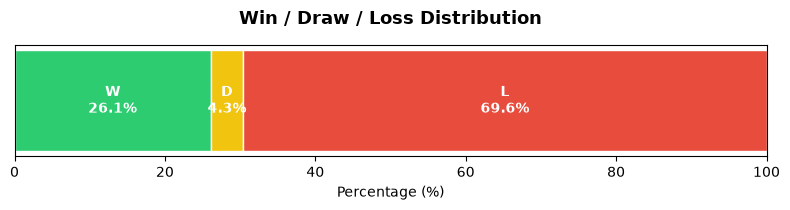

In [27]:

# Colors for W/D/L
colors = {"W": "#2ecc71", "D": "#f1c40f", "L": "#e74c3c"}

fig, ax = plt.subplots(figsize=(8, 2.2))

left = 0
for result in ["W", "D", "L"]:
    pct = wdl_summary.loc[result, "Rate (%)"]
    cnt = wdl_summary.loc[result, "Count"]
    ax.barh(
        y=0,
        width=pct,
        left=left,
        color=colors[result],
        edgecolor="white",
        height=0.6,
        label=f"{result} ({cnt})"
    )
    # Annotate inside the segment if it's wide enough
    if pct > 4:  # avoid clutter on tiny slices
        ax.text(
            left + pct / 2, 0,
            f"{result}\n{pct:.1f}%",
            ha="center", va="center",
            fontsize=10, fontweight="bold",
            color="white"
        )
    left += pct

# Clean up axes
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Percentage (%)")
ax.set_title("Win / Draw / Loss Distribution", fontsize=13, fontweight="bold", pad=15)

# Legend below the chart
"""
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=3,
    frameon=False
)"""

plt.tight_layout()
plt.show()

# Goals scored vs. Goals conceded

In [28]:
# Calculate goal metrics in Pandas
gf_total = df["GF"].sum()
ga_total = df["GA"].sum()
goal_diff = gf_total - ga_total

gf_avg = df["GF"].mean()
ga_avg = df["GA"].mean()

# Match-level differential
df["Goal_Diff"] = df["GF"] - df["GA"]

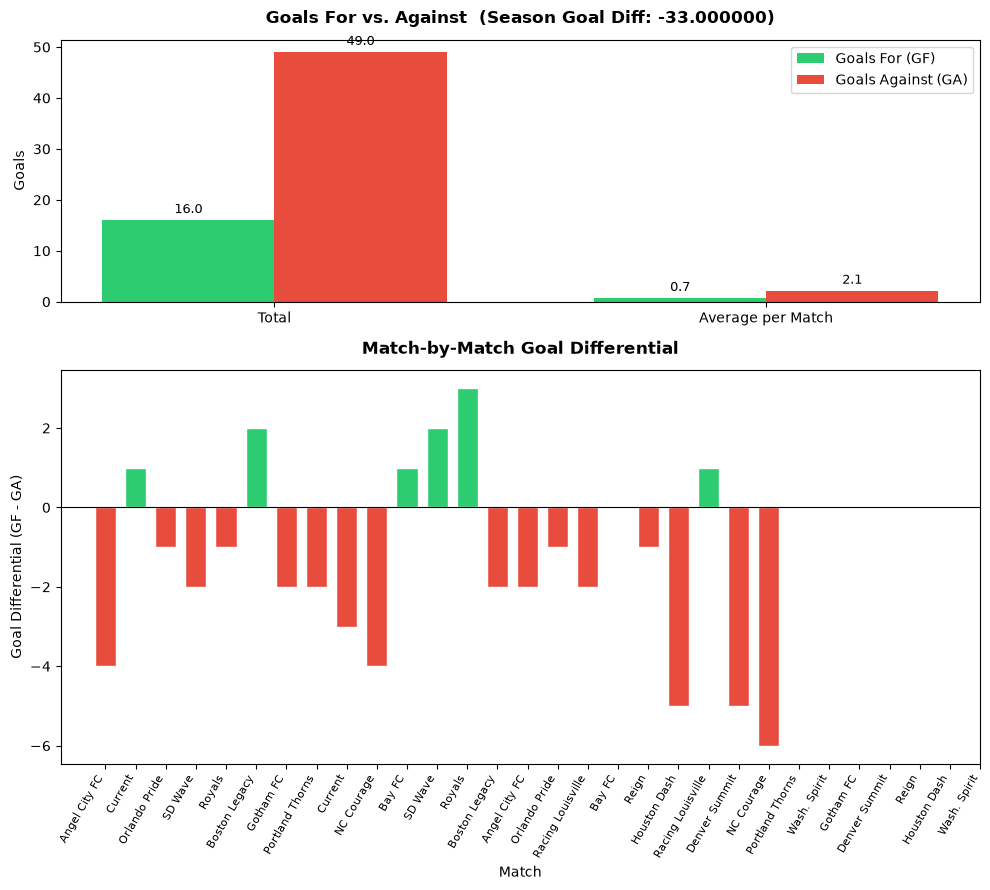

In [29]:

fig, axes = plt.subplots(2, 1, figsize=(10, 9), gridspec_kw={"height_ratios": [1, 1.5]})

# --- Plot 1: GF vs GA totals & averages ---
ax1 = axes[0]
categories = ["Total", "Average per Match"]
gf_vals = [gf_total, gf_avg]
ga_vals = [ga_total, ga_avg]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x - width/2, gf_vals, width, label="Goals For (GF)", color="#2ecc71")
bars2 = ax1.bar(x + width/2, ga_vals, width, label="Goals Against (GA)", color="#e74c3c")

ax1.bar_label(bars1, fmt="%.1f", padding=3, fontsize=9)
ax1.bar_label(bars2, fmt="%.1f", padding=3, fontsize=9)

ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.set_ylabel("Goals")
ax1.set_title(f"Goals For vs. Against  (Season Goal Diff: {goal_diff:0f})",
              fontsize=12, fontweight="bold", pad=12)
ax1.legend()

# --- Plot 2: Match-level goal differential ---
ax2 = axes[1]
match_idx = np.arange(len(df))
colors = np.where(df["Goal_Diff"] >= 0, "#2ecc71", "#e74c3c")

ax2.bar(match_idx, df["Goal_Diff"], color=colors, edgecolor="white", width=0.7)
ax2.axhline(0, color="black", linewidth=0.8)

ax2.set_xlabel("Match")
ax2.set_ylabel("Goal Differential (GF - GA)")
ax2.set_title("Match-by-Match Goal Differential", fontsize=12, fontweight="bold", pad=12)

# Use opponent names as x-tick labels if available, else match number
if "Opponent" in df.columns:
    ax2.set_xticks(match_idx)
    ax2.set_xticklabels(df["Opponent"], rotation=60, ha="right", fontsize=8)
else:
    ax2.set_xticks(match_idx[::max(1, len(df)//15)])

plt.tight_layout()
plt.show()

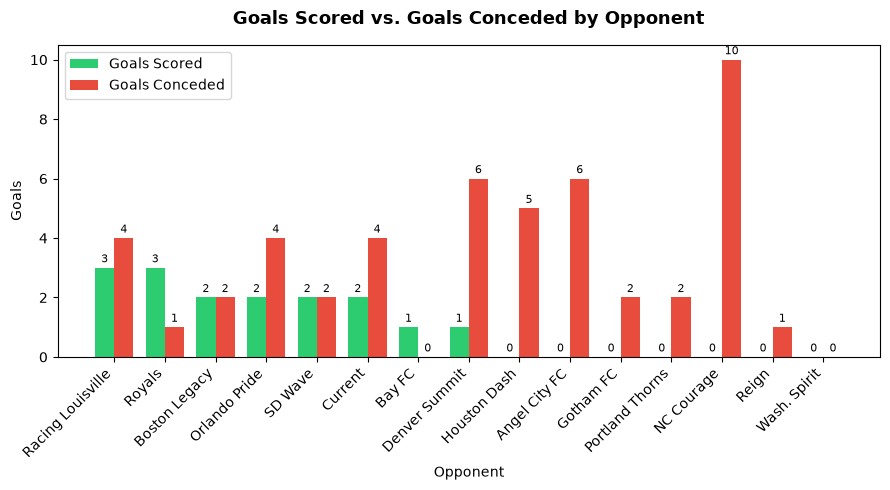

In [30]:
# Group by opponent, summing goals scored and conceded
goals_summary = df.groupby("Opponent")[["GF", "GA"]].sum()

# Sort opponents by total goals scored (optional, makes it easier to read)
goals_summary = goals_summary.sort_values("GF", ascending=False)

opponents = goals_summary.index
x = np.arange(len(opponents))
width = 0.38

fig, ax = plt.subplots(figsize=(max(8, len(opponents) * 0.6), 5))

bars1 = ax.bar(x - width/2, goals_summary["GF"], width,
                label="Goals Scored", color="#2ecc71")
bars2 = ax.bar(x + width/2, goals_summary["GA"], width,
                label="Goals Conceded", color="#e74c3c")

# Annotate bars with values
for bars in (bars1, bars2):
    ax.bar_label(bars, padding=2, fontsize=8)

ax.set_xlabel("Opponent")
ax.set_ylabel("Goals")
ax.set_title("Goals Scored vs. Goals Conceded by Opponent", fontsize=13, fontweight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(opponents, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

# Performance Analysis

In [31]:
# Calculate Points Per Match in Pandas
df["Points"] = df["Result"].map({"W": 3, "D": 1, "L": 0})

total_ppm = df["Points"].sum() / len(df)
ppm_by_venue = df.groupby("Venue")["Points"].mean()

In [32]:
ppm_by_venue

Venue
Away    0.428571
Home    1.444444
Name: Points, dtype: float64

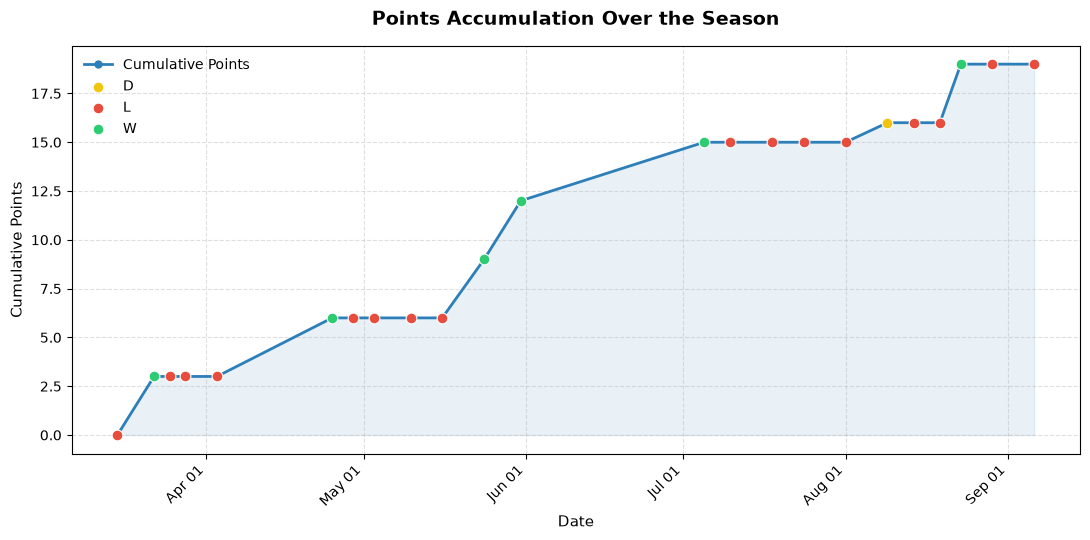

In [36]:


# Ensure Date is proper datetime and sorted
df = df.sort_values("Date")
df["Date"] = pd.to_datetime(df["Date"])

# Cumulative points (running total across the season)
df["Cumulative_Points"] = df["Points"].cumsum()

fig, ax = plt.subplots(figsize=(11, 5.5))

# Main line: cumulative points
ax.plot(df["Date"], df["Cumulative_Points"],
        marker="o", markersize=5, linewidth=2,
        color="#2c7fb8", label="Cumulative Points")

# Fill under the curve for visual weight
ax.fill_between(df["Date"], df["Cumulative_Points"], alpha=0.1, color="#2c7fb8")

# Color-code markers by result if available (W/D/L)
if "Result" in df.columns:
    color_map = {"W": "#2ecc71", "D": "#f1c40f", "L": "#e74c3c"}
    for result, group in df.groupby("Result"):
        ax.scatter(group["Date"], group["Cumulative_Points"],
                   color=color_map.get(result, "gray"), s=60, zorder=5,
                   label=f"{result}", edgecolor="white", linewidth=0.8)

# Format x-axis dates nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45)

# Labels, title, grid
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Cumulative Points", fontsize=11)
ax.set_title("Points Accumulation Over the Season", fontsize=14, fontweight="bold", pad=15)
ax.grid(True, linestyle="--", alpha=0.4)

# Annotate final total
final_date = df["Date"].iloc[-1]
final_points = df["Cumulative_Points"].iloc[-1]
ax.annotate(f"{final_points} pts",
            xy=(final_date, final_points),
            xytext=(10, 0), textcoords="offset points",
            fontsize=10, fontweight="bold", va="center")

ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

In [37]:
df["Rolling_PPM_5"] = df["Points"].rolling(5).mean()

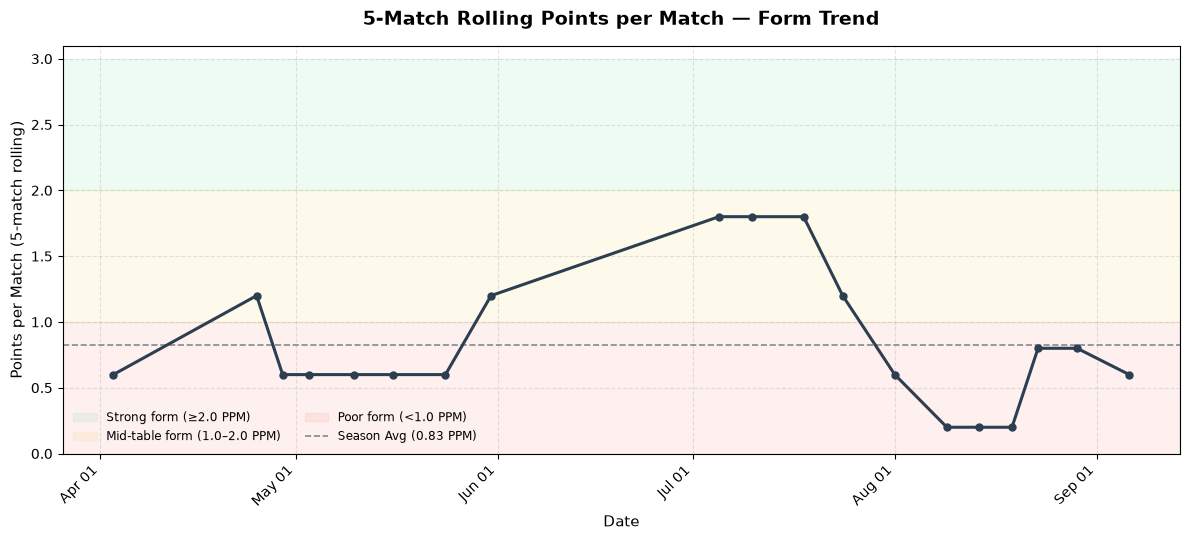

In [39]:


df = df.sort_values("Date")

fig, ax = plt.subplots(figsize=(12, 5.5))

# Shaded form zones for context (based on PPM benchmarks)
ax.axhspan(2.0, 3.0, color="#2ecc71", alpha=0.08, label="Strong form (≥2.0 PPM)")
ax.axhspan(1.0, 2.0, color="#f1c40f", alpha=0.08, label="Mid-table form (1.0–2.0 PPM)")
ax.axhspan(0.0, 1.0, color="#e74c3c", alpha=0.08, label="Poor form (<1.0 PPM)")

# Main rolling PPM line
ax.plot(df["Date"], df["Rolling_PPM_5"],
        marker="o", markersize=5, linewidth=2.2,
        color="#2c3e50", zorder=5)

# Reference line: overall season average PPM
season_avg = df["Points"].mean() if "Points" in df.columns else df["Rolling_PPM_5"].mean()
ax.axhline(season_avg, color="#7f8c8d", linestyle="--", linewidth=1.2,
           label=f"Season Avg ({season_avg:.2f} PPM)")

# Annotate current (latest) form
last_date = df["Date"].iloc[-1]
last_val = df["Rolling_PPM_5"].iloc[-1]
ax.annotate(f"{last_val:.2f}",
            xy=(last_date, last_val),
            xytext=(10, 5), textcoords="offset points",
            fontsize=10, fontweight="bold", color="#2c3e50")

# Date formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45)

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Points per Match (5-match rolling)", fontsize=11)
ax.set_title("5-Match Rolling Points per Match — Form Trend", fontsize=14, fontweight="bold", pad=15)
ax.set_ylim(0, 3.1)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="lower left", frameon=False, fontsize=8.5, ncol=2)

plt.tight_layout()
plt.show()

In [40]:
df["Goal_Difference"] = df["GF"] - df["GA"]

df["Rolling_GF"] = df["GF"].rolling(5).mean()
df["Rolling_GA"] = df["GA"].rolling(5).mean()

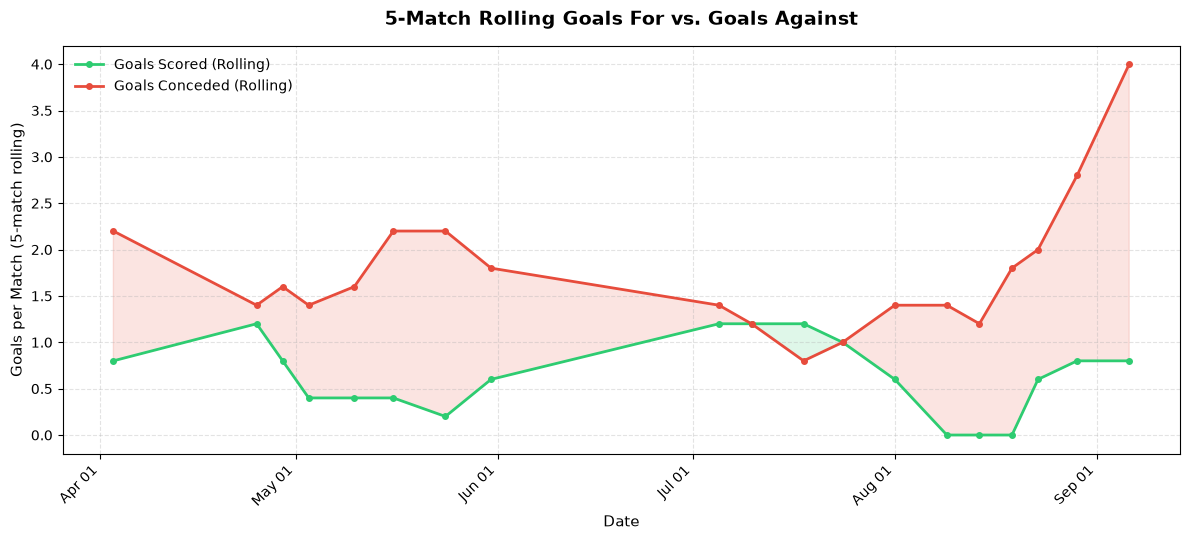

In [41]:


df = df.sort_values("Date")

fig, ax = plt.subplots(figsize=(12, 5.5))

# Main rolling lines
ax.plot(df["Date"], df["Rolling_GF"], marker="o", markersize=4,
        linewidth=2, color="#2ecc71", label="Goals Scored (Rolling)")
ax.plot(df["Date"], df["Rolling_GA"], marker="o", markersize=4,
        linewidth=2, color="#e74c3c", label="Goals Conceded (Rolling)")

# Shade the gap: green when scoring > conceding, red when the reverse
ax.fill_between(df["Date"], df["Rolling_GF"], df["Rolling_GA"],
                where=(df["Rolling_GF"] >= df["Rolling_GA"]),
                interpolate=True, color="#2ecc71", alpha=0.15)
ax.fill_between(df["Date"], df["Rolling_GF"], df["Rolling_GA"],
                where=(df["Rolling_GF"] < df["Rolling_GA"]),
                interpolate=True, color="#e74c3c", alpha=0.15)

# Annotate latest values
last_date = df["Date"].iloc[-1]
last_gf = df["Rolling_GF"].iloc[-1]
last_ga = df["Rolling_GA"].iloc[-1]
ax.annotate(f"{last_gf:.2f}", xy=(last_date, last_gf), xytext=(10, 0),
            textcoords="offset points", fontsize=9, fontweight="bold", color="#2ecc71")
ax.annotate(f"{last_ga:.2f}", xy=(last_date, last_ga), xytext=(10, 0),
            textcoords="offset points", fontsize=9, fontweight="bold", color="#e74c3c")

# Date formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45)

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Goals per Match (5-match rolling)", fontsize=11)
ax.set_title("5-Match Rolling Goals For vs. Goals Against", fontsize=14, fontweight="bold", pad=15)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

In [42]:
df["Rolling_Possession"] = df["Poss"].rolling(5).mean()

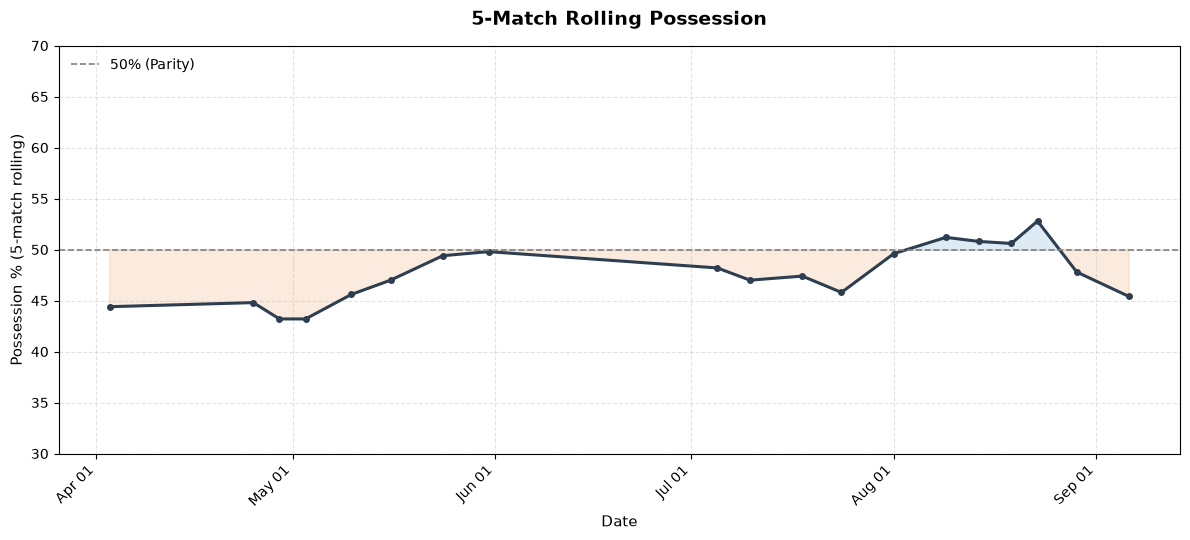

In [43]:

fig, ax = plt.subplots(figsize=(12, 5.5))

# Shade above/below 50% for quick read
ax.fill_between(df["Date"], df["Rolling_Possession"], 50,
                where=(df["Rolling_Possession"] >= 50),
                interpolate=True, color="#2c7fb8", alpha=0.15)
ax.fill_between(df["Date"], df["Rolling_Possession"], 50,
                where=(df["Rolling_Possession"] < 50),
                interpolate=True, color="#e67e22", alpha=0.15)

# Main line
ax.plot(df["Date"], df["Rolling_Possession"],
        marker="o", markersize=4, linewidth=2.2, color="#2c3e50")

# 50% reference line
ax.axhline(50, color="gray", linestyle="--", linewidth=1.2, label="50% (Parity)")

# Annotate latest value
last_date = df["Date"].iloc[-1]
last_val = df["Rolling_Possession"].iloc[-1]
ax.annotate(f"{last_val:.1f}%", xy=(last_date, last_val), xytext=(10, 0),
            textcoords="offset points", fontsize=10, fontweight="bold", color="#2c3e50")

# Date formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45)

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Possession % (5-match rolling)", fontsize=11)
ax.set_title("5-Match Rolling Possession", fontsize=14, fontweight="bold", pad=15)
ax.set_ylim(min(30, df["Rolling_Possession"].min() - 5), max(70, df["Rolling_Possession"].max() + 5))
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

# Possession vs. performance

In [44]:
# Calculate possession averages by match result
avg_possession = df.groupby("Result")["Poss"].agg(["count", "mean", "min", "max"])
avg_possession.columns = [
    "Matches",
    "Avg_Possession",
    "Min_Possession",
    "Max_Possession",
]

In [45]:
avg_possession

,Matches,Avg_Possession,Min_Possession,Max_Possession
Result,,,,
D,1,52.0000,52.0,52.0
L,16,46.1875,38.0,63.0
W,6,48.5000,42.0,57.0


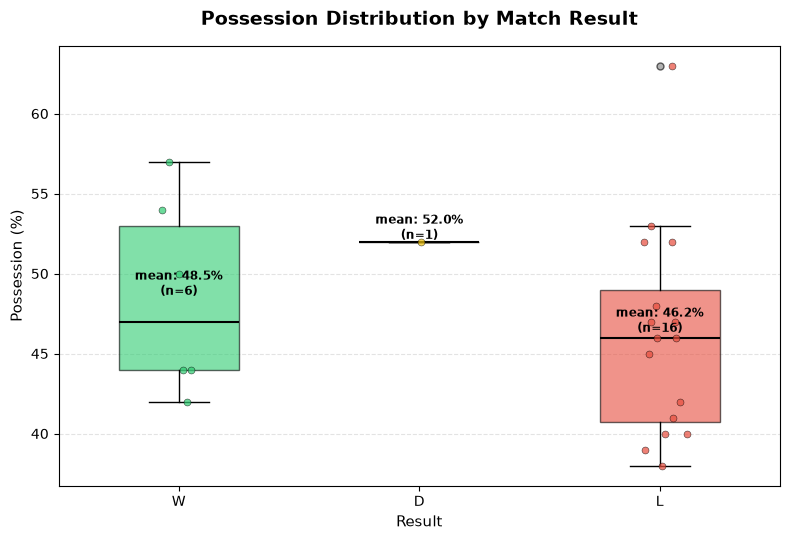

In [52]:


# Order groups logically: Win, Draw, Loss
order = ["W", "D", "L"]
colors = {"W": "#2ecc71", "D": "#f1c40f", "L": "#e74c3c"}

# Prepare data for each group, dropping NaNs
data = [df.loc[df["Result"] == r, "Poss"].dropna() for r in order]

fig, ax = plt.subplots(figsize=(8, 5.5))

bp = ax.boxplot(
    data,
    tick_labels=order,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(marker="o", markersize=5, markerfacecolor="gray", alpha=0.6)
)

# Color each box by result
for patch, r in zip(bp["boxes"], order):
    patch.set_facecolor(colors[r])
    patch.set_alpha(0.6)

# Overlay individual match points (jittered) for transparency on sample size
for i, r in enumerate(order):
    y = df.loc[df["Result"] == r, "Poss"].dropna()
    x = np.random.normal(i + 1, 0.05, size=len(y))  # jitter around box position
    ax.scatter(x, y, color=colors[r], edgecolor="black", linewidth=0.4,
               alpha=0.7, s=25, zorder=3)

# Annotate mean and match count above each box
for i, r in enumerate(order):
    vals = df.loc[df["Result"] == r, "Poss"].dropna()
    if len(vals) > 0:
        mean_val = vals.mean()
        ax.annotate(f"mean: {mean_val:.1f}%\n(n={len(vals)})",
                    xy=(i+1, vals.mean()),
                    xytext=(0, 2), textcoords="offset points",
                    ha="center", fontsize=8.5, fontweight="bold")

ax.set_xlabel("Result", fontsize=11)
ax.set_ylabel("Possession (%)", fontsize=11)
ax.set_title("Possession Distribution by Match Result", fontsize=14, fontweight="bold", pad=15)
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

# Formation analysis

In [53]:

# Team Formation Breakdown
team_table = (
    df.groupby("Formation")
    .agg(
        Matches=("Result", "count"),
        Win_Pct=("Result", lambda x: (x == "W").mean() * 100),
        GF_Match=("GF", "mean"),
        GA_Match=("GA", "mean"),
        Avg_Possession=("Poss", "mean"),
    )
    .reset_index()
)



In [55]:
# Sort by Win_Pct so best formations appear first
team_table_sorted = team_table.sort_values("Win_Pct", ascending=False).reset_index(drop=True)

styled = (
    team_table_sorted.style
    .background_gradient(subset=["Win_Pct"], cmap="Greens")
    .background_gradient(subset=["GF_Match"], cmap="Greens")
    .background_gradient(subset=["GA_Match"], cmap="Reds")
    .background_gradient(subset=["Avg_Possession"], cmap="Blues")
    .format({
        "Win_Pct": "{:.1f}%",
        "GF_Match": "{:.2f}",
        "GA_Match": "{:.2f}",
        "Avg_Possession": "{:.1f}%",
    })
    .set_caption("Team Performance by Formation")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}
    ])
)
styled

,Formation,Matches,Win_Pct,GF_Match,GA_Match,Avg_Possession
0,4-1-4-1,7,42.9%,0.86,0.71,47.9%
1,4-2-3-1,9,33.3%,1.00,1.89,46.1%
2,3-5-2,1,0.0%,0.00,4.00,46.0%
3,4-3-3,4,0.0%,0.00,3.00,50.2%
4,4-4-2,2,0.0%,0.50,5.50,42.5%


C:\Users\salma\AppData\Local\Temp\ipykernel_7588\2580377762.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(formations, rotation=45, ha="right", fontsize=9)
C:\Users\salma\AppData\Local\Temp\ipykernel_7588\2580377762.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(formations, rotation=45, ha="right", fontsize=9)
C:\Users\salma\AppData\Local\Temp\ipykernel_7588\2580377762.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(formations, rotation=45, ha="right", fontsize=9)
C:\Users\salma\AppData\Local\Temp\ipykernel_7588\2580377762.py:18: UserWarning: set_ticklabels() 

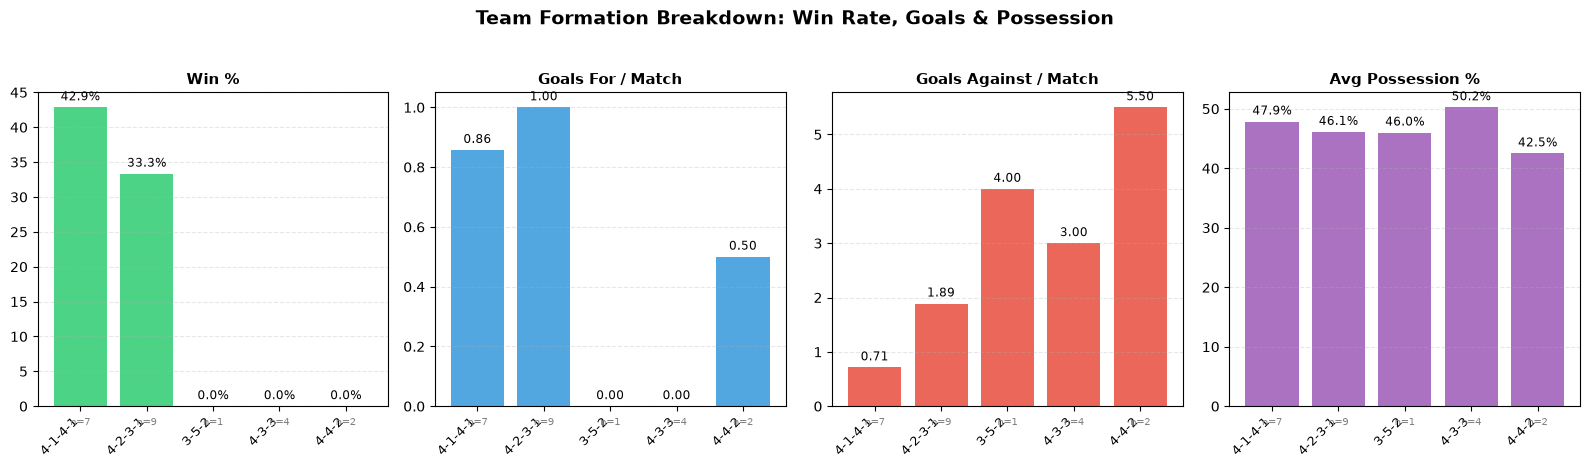

In [56]:

team_table_sorted = team_table.sort_values("Win_Pct", ascending=False)
formations = team_table_sorted["Formation"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=False)

metrics = [
    ("Win_Pct", "Win %", "#2ecc71", "{:.1f}%"),
    ("GF_Match", "Goals For / Match", "#3498db", "{:.2f}"),
    ("GA_Match", "Goals Against / Match", "#e74c3c", "{:.2f}"),
    ("Avg_Possession", "Avg Possession %", "#9b59b6", "{:.1f}%"),
]

for ax, (col, label, color, fmt) in zip(axes, metrics):
    bars = ax.bar(formations, team_table_sorted[col], color=color, alpha=0.85)
    ax.bar_label(bars, labels=[fmt.format(v) for v in team_table_sorted[col]],
                 padding=3, fontsize=8.5)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xticklabels(formations, rotation=45, ha="right", fontsize=9)
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)

# Also show match count as a subtitle under each formation
for ax in axes:
    for i, m in enumerate(team_table_sorted["Matches"]):
        ax.text(i, -0.06, f"n={m}", transform=ax.get_xaxis_transform(),
                ha="center", fontsize=7, color="gray")

fig.suptitle("Team Formation Breakdown: Win Rate, Goals & Possession",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# Coach / captain analysis

In [57]:
# Calculate W/D/L and performance metrics per Captain
df["Points"] = df["Result"].map({"W": 3, "D": 1, "L": 0})

captain_summary = (
    df.groupby("Captain")
    .agg(
        Matches=("Result", "count"),
        W=("Result", lambda x: (x == "W").sum()),
        D=("Result", lambda x: (x == "D").sum()),
        L=("Result", lambda x: (x == "L").sum()),
        Win_Pct=("Result", lambda x: (x == "W").mean() * 100),
        PPM=("Points", "mean"),
        GF_Match=("GF", "mean"),
        GA_Match=("GA", "mean"),
        Avg_Possession=("Poss", "mean"),
    )
    .reset_index()
)

In [58]:
captain_summary_sorted = captain_summary.sort_values("PPM", ascending=False).reset_index(drop=True)

styled = (
    captain_summary_sorted.style
    .background_gradient(subset=["Win_Pct"], cmap="Greens")
    .background_gradient(subset=["PPM"], cmap="Greens")
    .background_gradient(subset=["GF_Match"], cmap="Greens")
    .background_gradient(subset=["GA_Match"], cmap="Reds")
    .background_gradient(subset=["Avg_Possession"], cmap="Blues")
    .format({
        "Win_Pct": "{:.1f}%",
        "PPM": "{:.2f}",
        "GF_Match": "{:.2f}",
        "GA_Match": "{:.2f}",
        "Avg_Possession": "{:.1f}%",
    })
    .set_caption("Captain Performance Summary")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}
    ])
)
styled

,Captain,Matches,W,D,L,Win_Pct,PPM,GF_Match,GA_Match,Avg_Possession
0,Kathrin Hendrich,4,3,0,1,75.0%,2.25,1.25,0.25,44.8%
1,Mallory Swanson,6,2,0,4,33.3%,1.00,1.00,2.00,48.0%
2,Alyssa Naeher,9,1,0,8,11.1%,0.33,0.44,3.00,46.2%
3,Brianna Pinto,3,0,1,2,0.0%,0.33,0.00,1.00,53.7%
4,Samantha Staab,1,0,0,1,0.0%,0.00,1.00,6.00,38.0%


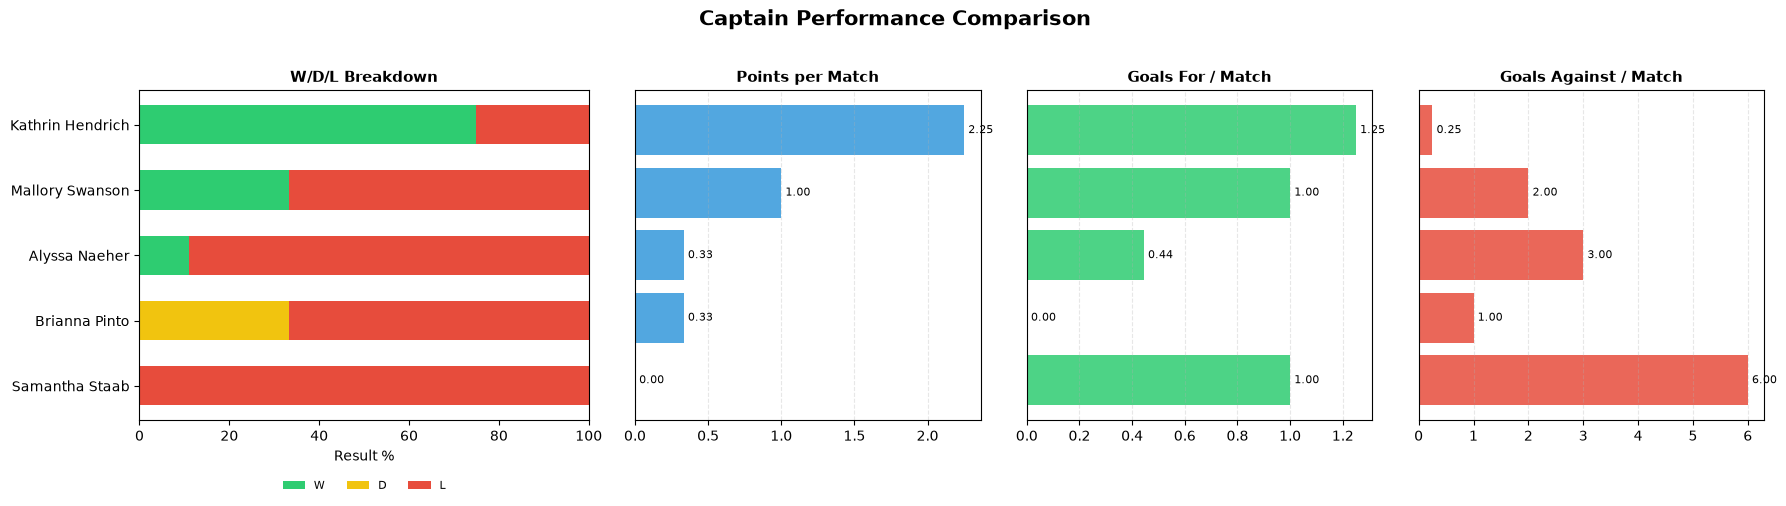

In [59]:
captain_summary_sorted = captain_summary.sort_values("PPM", ascending=False).reset_index(drop=True)
captains = captain_summary_sorted["Captain"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), gridspec_kw={"width_ratios": [1.3, 1, 1, 1]})

# --- Panel 1: 100% stacked W/D/L bar per captain ---
ax0 = axes[0]
wdl_pct = captain_summary_sorted[["W", "D", "L"]].div(captain_summary_sorted["Matches"], axis=0) * 100
colors_wdl = {"W": "#2ecc71", "D": "#f1c40f", "L": "#e74c3c"}

left = np.zeros(len(captains))
for col in ["W", "D", "L"]:
    ax0.barh(captains, wdl_pct[col], left=left, color=colors_wdl[col], label=col, height=0.6)
    left += wdl_pct[col].values

ax0.set_xlim(0, 100)
ax0.set_xlabel("Result %")
ax0.set_title("W/D/L Breakdown", fontsize=11, fontweight="bold")
ax0.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False, fontsize=8)
ax0.invert_yaxis()  # highest PPM captain on top

# --- Panels 2-4: PPM, GF/Match, GA/Match ---
metrics = [
    ("PPM", "Points per Match", "#3498db", "{:.2f}"),
    ("GF_Match", "Goals For / Match", "#2ecc71", "{:.2f}"),
    ("GA_Match", "Goals Against / Match", "#e74c3c", "{:.2f}"),
]

for ax, (col, label, color, fmt) in zip(axes[1:], metrics):
    bars = ax.barh(captains, captain_summary_sorted[col], color=color, alpha=0.85)
    ax.bar_label(bars, labels=[fmt.format(v) for v in captain_summary_sorted[col]],
                 padding=3, fontsize=8)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_yticks([])  # avoid repeating captain names on every panel
    ax.invert_yaxis()
    ax.grid(True, axis="x", linestyle="--", alpha=0.3)

fig.suptitle("Captain Performance Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Venue Analysis

In [60]:
# Calculate Home vs Away Metrics
venue_summary = (
    df.groupby("Venue")
    .agg(
        Matches=("Result", "count"),
        Win_Pct=("Result", lambda x: (x == "W").mean() * 100),
        GF_Match=("GF", "mean"),
        GA_Match=("GA", "mean"),
        Avg_Possession=("Poss", "mean"),
    )
    .reset_index()
)

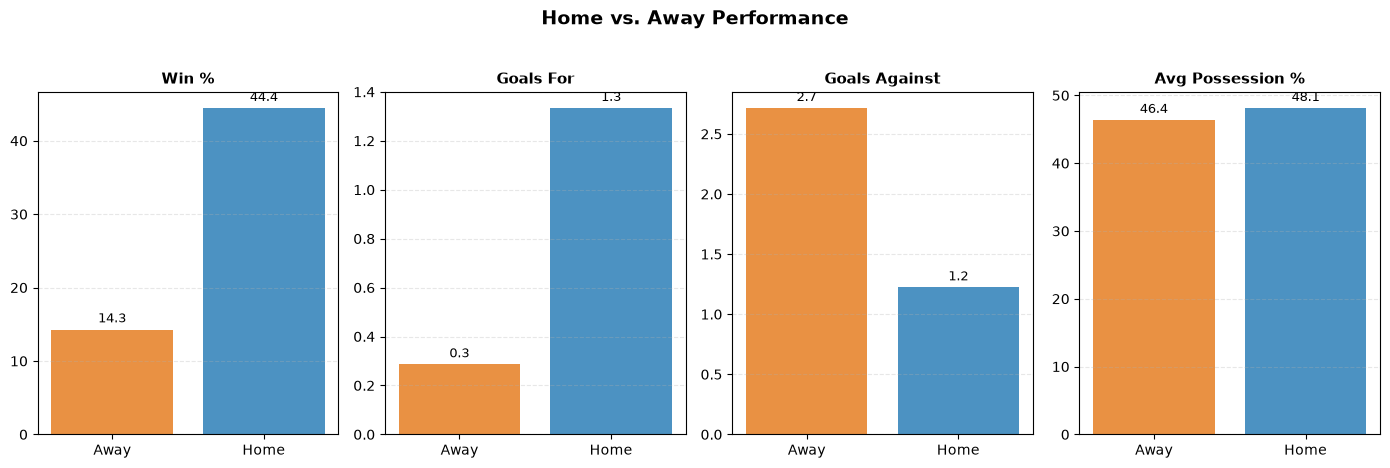

In [64]:

metrics = ["Win_Pct", "GF_Match", "GA_Match", "Avg_Possession"]
labels = ["Win %", "Goals For", "Goals Against", "Avg Possession %"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
colors = {"Home": "#2c7fb8", "Away": "#e67e22"}

for ax, metric, label in zip(axes, metrics, labels):
    bars = ax.bar(venue_summary["Venue"], venue_summary[metric],
                   color=[colors.get(v, "gray") for v in venue_summary["Venue"]], alpha=0.85)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    ax.set_title(label, fontsize=10.5, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)

fig.suptitle("Home vs. Away Performance", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

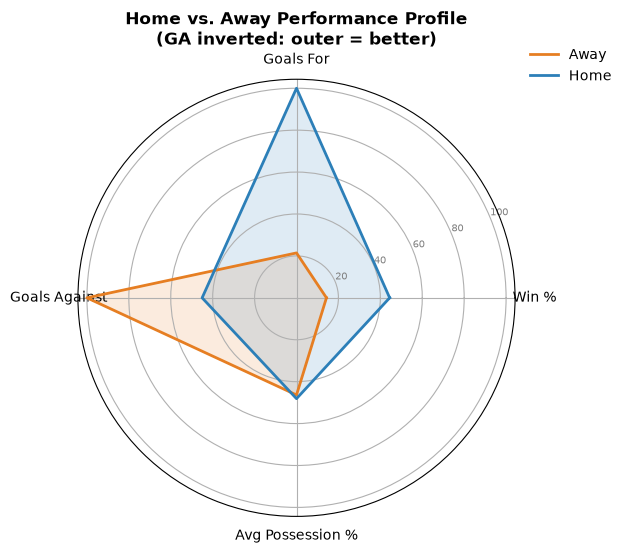

In [65]:




# Normalize each metric to 0-100 scale for fair radar comparison
# (GA_Match is inverted since lower is better defensively)
radar_df = venue_summary.set_index("Venue")[metrics].copy()
radar_df["GF_Match"] = radar_df["GF_Match"] / radar_df["GF_Match"].max() * 100
radar_df["GA_Match"] = ( radar_df["GA_Match"] / radar_df["GA_Match"].max()) * 100  # inverted
radar_df["Avg_Possession"] = radar_df["Avg_Possession"]  # already 0-100
radar_df["Win_Pct"] = radar_df["Win_Pct"]  # already 0-100

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(polar=True))
colors = {"Home": "#2c7fb8", "Away": "#e67e22"}

for venue in radar_df.index:
    values = radar_df.loc[venue].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=venue, color=colors.get(venue, "gray"))
    ax.fill(angles, values, alpha=0.15, color=colors.get(venue, "gray"))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(["20", "40", "60", "80", "100"], fontsize=7, color="gray")
ax.set_title("Home vs. Away Performance Profile\n(GA inverted: outer = better)",
              fontsize=12, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), frameon=False)

plt.tight_layout()
plt.show()

# Opponent analysis

In [66]:


opp_summary = (
    df.groupby("Opponent")
    .agg(
        Matches=("Result", "count"),
        Wins=("Result", lambda x: (x == "W").sum()),
        Draws=("Result", lambda x: (x == "D").sum()),
        Losses=("Result", lambda x: (x == "L").sum()),
        Win_Pct=("Result", lambda x: (x == "W").mean() * 100),
        GF=("GF", "sum"),
        GA=("GA", "sum"),
        Points=("Points", "sum"),
    )
    .reset_index()
)

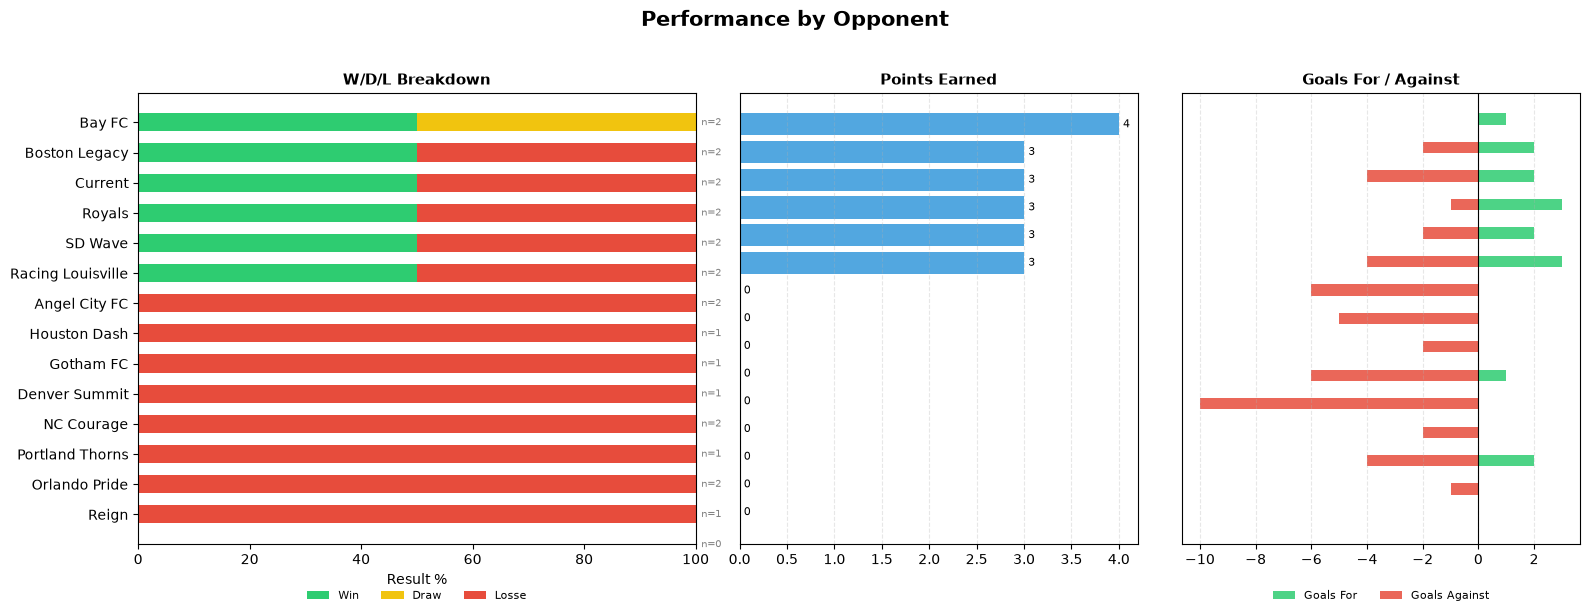

In [67]:


# Sort by total points earned against each opponent
opp_summary_sorted = opp_summary.sort_values("Points", ascending=False).reset_index(drop=True)
opponents = opp_summary_sorted["Opponent"]

fig, axes = plt.subplots(1, 3, figsize=(16, max(5, len(opponents) * 0.4)),
                          gridspec_kw={"width_ratios": [1.4, 1, 1]})

# --- Panel 1: 100% stacked W/D/L per opponent ---
ax0 = axes[0]
wdl_pct = opp_summary_sorted[["Wins", "Draws", "Losses"]].div(opp_summary_sorted["Matches"], axis=0) * 100
colors_wdl = {"Wins": "#2ecc71", "Draws": "#f1c40f", "Losses": "#e74c3c"}

left = np.zeros(len(opponents))
for col in ["Wins", "Draws", "Losses"]:
    ax0.barh(opponents, wdl_pct[col], left=left, color=colors_wdl[col], label=col.rstrip("s"), height=0.6)
    left += wdl_pct[col].values

ax0.set_xlim(0, 100)
ax0.set_xlabel("Result %")
ax0.set_title("W/D/L Breakdown", fontsize=11, fontweight="bold")
ax0.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False, fontsize=8)
ax0.invert_yaxis()  # top scorer on top

# Annotate match count next to each opponent's bar
for i, n in enumerate(opp_summary_sorted["Matches"]):
    ax0.text(101, i, f"n={n}", va="center", fontsize=7.5, color="gray")

# --- Panel 2: Points earned ---
ax1 = axes[1]
bars1 = ax1.barh(opponents, opp_summary_sorted["Points"], color="#3498db", alpha=0.85)
ax1.bar_label(bars1, padding=3, fontsize=8)
ax1.set_title("Points Earned", fontsize=11, fontweight="bold")
ax1.set_yticks([])
ax1.invert_yaxis()
ax1.grid(True, axis="x", linestyle="--", alpha=0.3)

# --- Panel 3: GF vs GA (diverging) ---
ax2 = axes[2]
y_pos = np.arange(len(opponents))
ax2.barh(y_pos, opp_summary_sorted["GF"], color="#2ecc71", alpha=0.85, label="Goals For", height=0.4)
ax2.barh(y_pos, -opp_summary_sorted["GA"], color="#e74c3c", alpha=0.85, label="Goals Against", height=0.4)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_title("Goals For / Against", fontsize=11, fontweight="bold")
ax2.set_yticks([])
ax2.invert_yaxis()
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False, fontsize=8)
ax2.grid(True, axis="x", linestyle="--", alpha=0.3)

fig.suptitle("Performance by Opponent", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()